Research Question 3: How does the time between winning possession in your own half and the first shot correlate with the probability of scoring (based on xGoals)?

Retrieving the Data:

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

import soccerdata as sd


data = sd.WhoScored(leagues="GER-Bundesliga", seasons="2024/2025", headless=True)

# Creating a list of all the game IDs of the Bundesliga season 2024/2025
game_ids = data.read_schedule()["game_id"].to_list()

events = data.read_events(match_id=game_ids)

# Defining possession IDs for each possession
events["poss_change"] = events["team_id"] != events["team_id"].shift()
events["possession_id"] = events["poss_change"].cumsum()

shot_types = ["Goal", "MissedShots", "SavedShot", "ShotOnPost"]
events["is_shot"] = events["type"].isin(shot_types)

possessions_with_shot = events.groupby("possession_id")["is_shot"].transform("any")

shot_results = events[events["is_shot"]].groupby("possession_id")["is_goal"].any()

possession_win = ["Tackle", "Interception", "BallRecovery"]

# Determining the time difference between possession gain and shot
events["poss_gain_time"] = (events["minute"] * 60) + events["second"]
first_shot_time = events[events["is_shot"]].groupby("possession_id")["poss_gain_time"].min()

# Filter for all events that were a possession gain in the own half, which resulted in a shot
own_half_wins_with_shot = events[
    (events["type"].isin(possession_win)) & 
    (events["outcome_type"] == "Successful") & 
    (events["x"] < 50) &
    (events["poss_change"] == True) &
    (possessions_with_shot)
].copy()

own_half_wins_with_shot = own_half_wins_with_shot.sort_values("poss_gain_time").drop_duplicates("possession_id", keep="first")
# Merge the first_shot_time table
own_half_wins_with_shot["shot_time"] = own_half_wins_with_shot["possession_id"].map(first_shot_time)

own_half_wins_with_shot["time_delta"] = own_half_wins_with_shot["shot_time"] - own_half_wins_with_shot["poss_gain_time"]

# Merge the shot_result table
own_half_wins_with_shot["is_goal"] = own_half_wins_with_shot["possession_id"].map(shot_results)

# Make a dataframe with only the relevant data
df_RQ3 = own_half_wins_with_shot[["is_goal","time_delta"]].copy()

df_RQ3 = df_RQ3.sort_values(by="time_delta")

df_RQ3.to_json("RQ3.json", orient="records", indent=4)
df_RQ3.to_csv("RQ3.csv", index=False)


[03/16/26 20:16:39] INFO     No custom team name replacements found. You can configure these in       ]8;id=36961;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=711964;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#92\92]8;;\
                             C:\Users\hinri\soccerdata\config\teamname_replacements.json.                          

                    INFO     No custom league dict found. You can configure additional leagues in    ]8;id=96765;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py\_config.py]8;;\:]8;id=948942;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_config.py#198\198]8;;\
                             C:\Users\hinri\soccerdata\config\league_dict.json.                                    

                    INFO     Saving cached data to C:\Users\hinri\soccerdata\data\WhoScored          ]8;id=583432;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py\_common.py]8;;\:]8;id=882331;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\_common.py#249\249]8;;\

[03/16/26 20:16:44] INFO     Retrieving calendar for GER-Bundesliga 2425                           ]8;id=444619;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=241157;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#365\365]8;;\

                    INFO     [1/10] Retrieving fixtures for GER-Bundesliga 2425                    ]8;id=900018;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=383131;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#396\396]8;;\

...

                    INFO     [302/306] Retrieving game with id=1834455                             ]8;id=981657;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=753863;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [303/306] Retrieving game with id=1834451                             ]8;id=810747;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=766666;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [304/306] Retrieving game with id=1834459                             ]8;id=634053;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=780036;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [305/306] Retrieving game with id=1834447                             ]8;id=778349;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=265545;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

                    INFO     [306/306] Retrieving game with id=1834463                             ]8;id=922777;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py\whoscored.py]8;;\:]8;id=145879;file://C:\Users\hinri\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\soccerdata\whoscored.py#688\688]8;;\

Creating the Visualization:

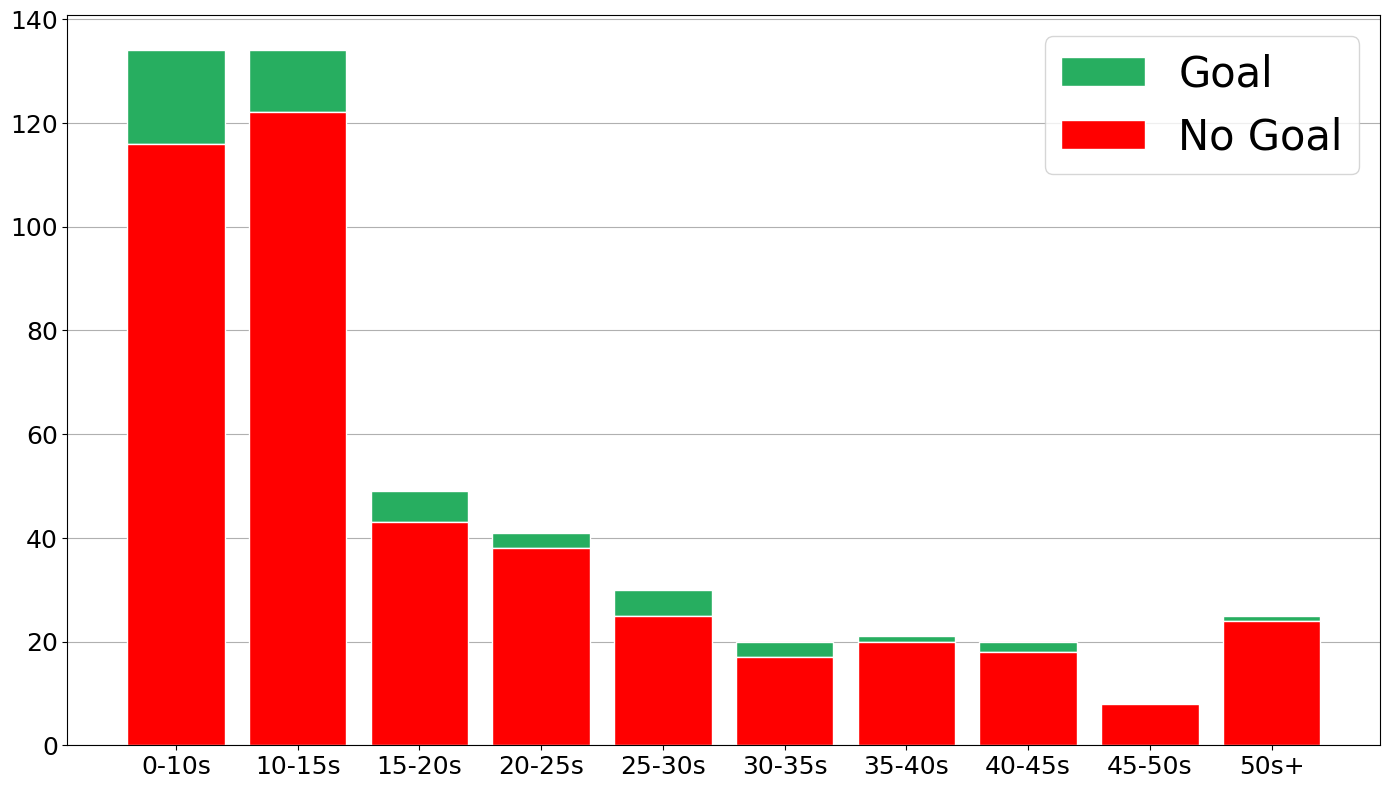

In [15]:
# Defining intervalls
bins = [0, 10, 15, 20, 25, 30, 35, 40, 45, 50, float("inf")]
labels = ["0-10s", "10-15s", "15-20s", "20-25s", "25-30s", "30-35s", "35-40s", "40-45s", "45-50s", "50s+"]

# Assigning intervalls to each element of the dataframe
df_RQ3["intervalls"] = pd.cut(
    df_RQ3["time_delta"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

goals = []
no_goals = []

for label in labels:
    subset = df_RQ3[df_RQ3["intervalls"] == label]

    g = int(subset[subset["is_goal"]==True].shape[0])
    ng = int(subset[subset["is_goal"] == False].shape[0])

    goals.append(g)
    no_goals.append(ng)

plt.figure(figsize=(14, 8))

ax = plt.gca()
ax.set_axisbelow(True)

plt.grid(axis="y")

plt.bar(labels, goals, bottom=no_goals, color="#27ae60", label="Goal", edgecolor="white")
plt.bar(labels, no_goals, color="#FF0000", label="No Goal", edgecolor="white")

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(["Goal", "No Goal"], fontsize=30)

plt.tight_layout()

plt.savefig("GoalsBarRQ3.png")

plt.show()

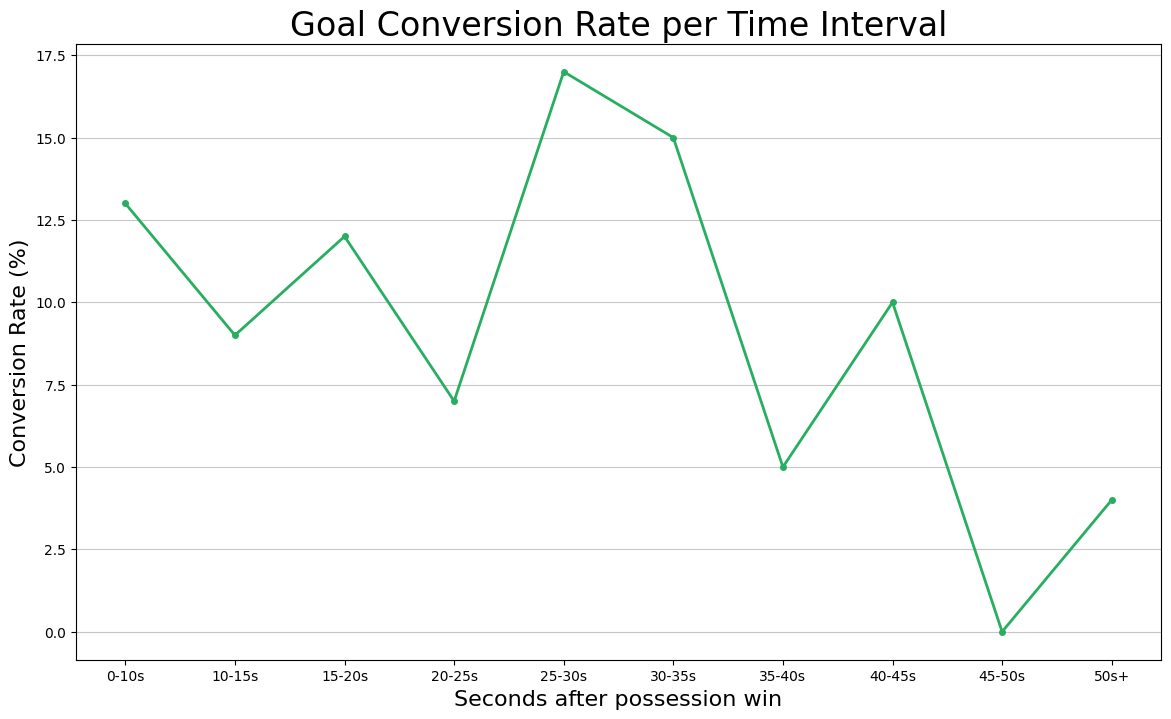

In [3]:
percentages = []
for x in range(len(goals)):
    percentages.append(round(goals[x]/(no_goals[x]+goals[x])*100))

plt.figure(figsize=(14, 8))

plt.plot(labels, percentages, color="#27ae60", marker='.', linewidth=2, markersize=8)

ax = plt.gca()
ax.set_axisbelow(True)
plt.grid(axis="y", linestyle='-', alpha=0.7)

plt.title("Goal Conversion Rate per Time Interval", fontsize=24)
plt.xlabel("Seconds after possession win", fontsize=16)
plt.ylabel("Conversion Rate (%)", fontsize=16)

plt.savefig("GoalsLineRQ3.png")

plt.show()